# Phase 1: Data Preparation — Kaggle Version
## Voice Biometric Authentication System

### Before running — add these datasets in Kaggle:
1. Click **+ Add Data** (top right)
2. Search **`asvpoof-2019-dataset`** → Add
3. Search **`librispeech-clean`** → Add
4. Upload your own voice zip → Add

### Then enable Internet:
- Right panel → Session options → Internet ON

### Enable GPU:
- Right panel → Accelerator → GPU P100

In [1]:
# ── Debug: Print everything Kaggle sees ───────────────────────────────────────
import os, glob

print('=== /kaggle/input/ contents ===')
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:                          # only show files 3 levels deep
        for f in files[:5]:
            print(f'{indent}  {f}')
        if len(files) > 5:
            print(f'{indent}  ... ({len(files)-5} more files)')


=== /kaggle/input/ contents ===
input/
  datasets/
    abhi2007798/
      aaaa6666/
        my_voice_data/
          text_independent/
          text_dependent/
            phrase1/
            phrase3/
            phrase2/
      asvpoof/
        asvspoof/


In [2]:
!pip install -q librosa soundfile webrtcvad
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Done.


In [3]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
import pickle
import struct
import webrtcvad
from pathlib import Path
from sklearn.model_selection import train_test_split
from IPython.display import Audio, display

# ── Kaggle Paths ──────────────────────────────────────────────────────────────
WORKING_DIR  = '/kaggle/working'
INPUT_DIR    = '/kaggle/input'

# Output folders (persist as notebook output)
BASE_DIR = f'{WORKING_DIR}/voice_auth'

dirs = [
    f'{BASE_DIR}/data/processed/genuine',
    f'{BASE_DIR}/data/processed/impostor',
    f'{BASE_DIR}/data/processed/spoof',
    f'{BASE_DIR}/data/features/mfcc',
    f'{BASE_DIR}/data/features/melspec',
    f'{BASE_DIR}/models',
    f'{BASE_DIR}/results',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# ── Audio Config ──────────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MFCC      = 40
N_MELS      = 80
HOP_LENGTH  = 160
WIN_LENGTH  = 400
N_FFT       = 512
CLIP_DUR    = 3.0

SPEAKER_NAME = 'abhiram'   # change to your name

print(f'Working dir : {BASE_DIR}')
print(f'Sample rate : {SAMPLE_RATE} Hz')

Working dir : /kaggle/working/voice_auth
Sample rate : 16000 Hz


## Step 1: Find Your Voice Data
Upload your `my_voice_data.zip` as a Kaggle dataset, then run this cell.

In [4]:
import zipfile, shutil

VOICE_RAW_DIR = f'{BASE_DIR}/data/raw/genuine'
os.makedirs(VOICE_RAW_DIR, exist_ok=True)

# ── Step 1: Try to find a zip and extract it ──────────────────────────────────
zips = glob.glob('/kaggle/input/**/*.zip', recursive=True)
if zips:
    print(f'Found zip: {zips[0]}')
    with zipfile.ZipFile(zips[0], 'r') as z:
        z.extractall(VOICE_RAW_DIR)
    print('Extracted.')

# ── Step 2: Kaggle auto-extracts zips — search WAV files directly ─────────────
# Find all WAV files anywhere under /kaggle/input/
all_input_wavs = glob.glob('/kaggle/input/**/*.wav', recursive=True)
print(f'\nWAV files found in /kaggle/input/: {len(all_input_wavs)}')
for f in all_input_wavs[:10]:
    print(f'  {f}')

# Copy them to our working directory
if all_input_wavs:
    copied = 0
    for src in all_input_wavs:
        dst = f'{VOICE_RAW_DIR}/{Path(src).name}'
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1
    print(f'\nCopied {copied} WAV files to {VOICE_RAW_DIR}')

# ── Step 3: Final count ───────────────────────────────────────────────────────
voice_files = glob.glob(f'{VOICE_RAW_DIR}/**/*.wav', recursive=True)
print(f'Your voice files ready: {len(voice_files)}')

if len(voice_files) == 0:
    print()
    print('STILL 0? Check these steps:')
    print('  1. Click + Add Data in Kaggle')
    print('  2. Go to Your Datasets tab (not Search)')
    print('  3. Select your uploaded voice dataset')
    print('  4. Restart kernel and run again')



WAV files found in /kaggle/input/: 136
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_015.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_003.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_001.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/sample_22.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/sample_19.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/sample_21.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_019.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_011.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_005.wav
  /kaggle/input/datasets/abhi2007798/aaaa6666/my_voice_data/text_independent/abhiram_free_017.wav



## Step 2: Load LibriSpeech (Impostor Voices)

In [5]:
from collections import defaultdict

# Find LibriSpeech in attached datasets
libri_paths = glob.glob(f'{INPUT_DIR}/*libri*/**/*.flac', recursive=True) + \
              glob.glob(f'{INPUT_DIR}/*libri*/**/*.wav',  recursive=True)

if libri_paths:
    print(f'LibriSpeech files found: {len(libri_paths)}')
else:
    # Download directly (Internet must be ON)
    print('LibriSpeech not found in datasets. Downloading test-clean (~346MB)...')
    import torchaudio
    libri_dl_dir = f'{BASE_DIR}/data/raw/librispeech'
    os.makedirs(libri_dl_dir, exist_ok=True)
    libri_dataset = torchaudio.datasets.LIBRISPEECH(
        root=libri_dl_dir, url='test-clean', download=True
    )
    libri_paths = glob.glob(f'{libri_dl_dir}/**/*.flac', recursive=True)
    print(f'Downloaded: {len(libri_paths)} files')

# Group by speaker (folder name = speaker id in LibriSpeech)
speaker_files = defaultdict(list)
for f in libri_paths:
    spk = Path(f).parts[-3]  # LibriSpeech folder structure: speaker/chapter/file
    speaker_files[spk].append(f)

print(f'Unique speakers : {len(speaker_files)}')

LibriSpeech not found in datasets. Downloading test-clean (~346MB)...


100%|██████████| 331M/331M [00:50<00:00, 6.87MB/s]


Downloaded: 2620 files
Unique speakers : 40


In [6]:
# Save 20 speakers x 20 utterances as impostor WAVs
IMPOSTOR_DIR = f'{BASE_DIR}/data/processed/impostor'
NUM_SPK = 20
NUM_UTT = 20

selected_spks = list(speaker_files.keys())[:NUM_SPK]
saved = 0
for spk in selected_spks:
    for i, f in enumerate(speaker_files[spk][:NUM_UTT]):
        audio, sr = librosa.load(f, sr=SAMPLE_RATE, mono=True)
        audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.9
        target = int(SAMPLE_RATE * CLIP_DUR)
        audio  = audio[:target] if len(audio) >= target else np.pad(audio, (0, target - len(audio)))
        out    = f'{IMPOSTOR_DIR}/spk{spk}_{i:03d}.wav'
        sf.write(out, audio, SAMPLE_RATE)
        saved += 1

print(f'Impostor files saved: {saved}')

Impostor files saved: 400


## Step 3: Load ASVspoof 2019 (Spoof / DeepFake)

In [7]:
SPOOF_OUT = f'{BASE_DIR}/data/processed/spoof'

# Try attached Kaggle dataset first
asv_protocols = glob.glob(f'{INPUT_DIR}/*asvspoof*/**/*.txt', recursive=True) + \
                glob.glob(f'{INPUT_DIR}/*asvpoof*/**/*.txt',  recursive=True)
asv_audio     = glob.glob(f'{INPUT_DIR}/*asvspoof*/**/*.flac', recursive=True) + \
                glob.glob(f'{INPUT_DIR}/*asvpoof*/**/*.flac',  recursive=True)

print(f'ASVspoof protocol files : {len(asv_protocols)}')
print(f'ASVspoof audio files    : {len(asv_audio)}')

if asv_audio:
    audio_lookup = {Path(f).stem: f for f in asv_audio}

    if asv_protocols:
        df_proto = pd.read_csv(asv_protocols[0], sep=' ', header=None,
                               names=['speaker','file','env','attack','label'])
        print('Label counts:', df_proto['label'].value_counts().to_dict())
        spoof_ids   = df_proto[df_proto['label']=='spoof'  ]['file'].tolist()[:500]
        genuine_ids = df_proto[df_proto['label']=='bonafide']['file'].tolist()[:200]
    else:
        spoof_ids   = list(audio_lookup.keys())[:500]
        genuine_ids = []

    saved_s = saved_g = 0
    for fid in spoof_ids:
        src = audio_lookup.get(fid)
        if src is None: continue
        audio, sr = librosa.load(src, sr=SAMPLE_RATE, mono=True)
        audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.9
        target = int(SAMPLE_RATE * CLIP_DUR)
        audio  = audio[:target] if len(audio) >= target else np.pad(audio, (0, target-len(audio)))
        sf.write(f'{SPOOF_OUT}/asv_spoof_{fid}.wav', audio, SAMPLE_RATE)
        saved_s += 1

    print(f'ASVspoof files saved: {saved_s} spoof')

else:
    print('ASVspoof not found. Generating TTS spoof instead...')

ASVspoof protocol files : 0
ASVspoof audio files    : 0
ASVspoof not found. Generating TTS spoof instead...


In [8]:
# Fallback: Generate spoof with gTTS if ASVspoof not attached
spoof_existing = glob.glob(f'{SPOOF_OUT}/*.wav')

if len(spoof_existing) < 50:
    print('Generating TTS spoof samples with gTTS...')
    !pip install -q gtts pydub
    from gtts import gTTS
    from pydub import AudioSegment
    import io

    PHRASES = [
        'My voice is my password',
        'Open sesame authenticate now',
        'Verify my identity please',
        'The quick brown fox jumps over the lazy dog',
        'Speech recognition systems use deep neural networks',
        'Biometric authentication verifies human identity',
        'Count from one to twenty slowly',
        'Deep learning has revolutionised speaker verification',
        'Hello my name is a computer generated voice',
        'This is a synthetic speech sample for testing',
    ]
    TLDS = ['com', 'co.uk', 'com.au', 'co.in', 'ca']

    count = 0
    for t_idx, tld in enumerate(TLDS):
        for p_idx, phrase in enumerate(PHRASES):
            out_path = f'{SPOOF_OUT}/gtts_{tld.replace(".","_")}_{p_idx:02d}.wav'
            if os.path.exists(out_path):
                count += 1
                continue
            try:
                tts_g  = gTTS(text=phrase, lang='en', tld=tld)
                buf    = io.BytesIO()
                tts_g.write_to_fp(buf)
                buf.seek(0)
                seg = AudioSegment.from_mp3(buf)
                wav_buf = io.BytesIO()
                seg.export(wav_buf, format='wav')
                wav_buf.seek(0)
                audio, sr = librosa.load(wav_buf, sr=SAMPLE_RATE, mono=True)
                audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.9
                target = int(SAMPLE_RATE * CLIP_DUR)
                audio  = audio[:target] if len(audio) >= target else np.pad(audio,(0,target-len(audio)))
                sf.write(out_path, audio, SAMPLE_RATE)
                count += 1
            except Exception as e:
                print(f'  gTTS error ({tld}/{p_idx}): {e}')

    print(f'Generated {count} TTS spoof samples.')
else:
    print(f'Already have {len(spoof_existing)} spoof files. Skipping TTS generation.')

Generating TTS spoof samples with gTTS...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Generated 50 TTS spoof samples.


## Step 4: Preprocess Your Voice (Genuine)

In [9]:
def preprocess_audio(filepath, target_sr=16000, duration=3.0):
    try:
        audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
        # Normalize
        audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.9
        # Trim silence
        audio, _ = librosa.effects.trim(audio, top_db=20)
        # Clip/pad
        target_len = int(target_sr * duration)
        audio = audio[:target_len] if len(audio) >= target_len \
                else np.pad(audio, (0, target_len - len(audio)))
        return audio.astype(np.float32)
    except Exception as e:
        print(f'  Error: {filepath} — {e}')
        return None


GENUINE_OUT = f'{BASE_DIR}/data/processed/genuine'
voice_raw   = glob.glob(f'{VOICE_RAW_DIR}/**/*.wav', recursive=True)
print(f'Processing {len(voice_raw)} genuine files...')

saved = 0
for f in voice_raw:
    audio = preprocess_audio(f)
    if audio is None: continue
    out = f'{GENUINE_OUT}/{Path(f).stem}.wav'
    sf.write(out, audio, SAMPLE_RATE)
    saved += 1

print(f'Genuine files processed: {saved}')

Processing 136 genuine files...


/tmp/ipykernel_23/2586918463.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_23/2586918463.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_23/2586918463.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filepath, sr=target_sr, mono=

Genuine files processed: 136


## Step 5: Feature Extraction (MFCC + Mel-Spectrogram)

In [10]:
def extract_mfcc(audio, sr=16000):
    mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.vstack([mfcc, delta, delta2])  # (120, T)

def extract_melspec(audio, sr=16000):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    return librosa.power_to_db(mel, ref=np.max)  # (80, T)

all_records = []

label_dirs = {
    'genuine' : f'{BASE_DIR}/data/processed/genuine',
    'impostor': f'{BASE_DIR}/data/processed/impostor',
    'spoof'   : f'{BASE_DIR}/data/processed/spoof',
}

for label, src_dir in label_dirs.items():
    files = glob.glob(f'{src_dir}/*.wav')
    print(f'Extracting features for {label}: {len(files)} files')
    for f in files:
        audio, _ = librosa.load(f, sr=SAMPLE_RATE)
        mfcc_feat = extract_mfcc(audio)
        mel_feat  = extract_melspec(audio)
        base      = Path(f).stem
        mfcc_path = f'{BASE_DIR}/data/features/mfcc/{base}.npy'
        mel_path  = f'{BASE_DIR}/data/features/melspec/{base}.npy'
        np.save(mfcc_path, mfcc_feat)
        np.save(mel_path,  mel_feat)
        all_records.append({
            'audio_file'  : f,
            'mfcc_file'   : mfcc_path,
            'melspec_file': mel_path,
            'label'       : label,
        })

df_all = pd.DataFrame(all_records)
df_all.to_csv(f'{BASE_DIR}/data/features_index.csv', index=False)
print(f'\nTotal features extracted: {len(df_all)}')
print(df_all['label'].value_counts())

Extracting features for genuine: 136 files
Extracting features for impostor: 400 files
Extracting features for spoof: 50 files

Total features extracted: 586
label
impostor    400
genuine     136
spoof        50
Name: count, dtype: int64


In [11]:
# ── Fix Class Imbalance ───────────────────────────────────────────────────────
# Target: ~400 samples per class
# Strategy:
#   genuine (136 → 400) : audio augmentation
#   spoof   ( 50 → 400) : more gTTS phrases + augmentation
#   impostor (400)      : already balanced, keep as is

TARGET = 400

# ─────────────────────────────────────────────────────────────────────────────
# Part A: Augment genuine samples
# ─────────────────────────────────────────────────────────────────────────────
import random, itertools

genuine_wavs = glob.glob(f'{BASE_DIR}/data/processed/genuine/*.wav')
needed       = TARGET - len(genuine_wavs)
print(f'Genuine: {len(genuine_wavs)} existing, need {needed} augmented copies')

def augment_audio(audio, sr, aug_type):
    if aug_type == 'noise':
        noise = np.random.normal(0, 0.005, len(audio)).astype(np.float32)
        return audio + noise
    elif aug_type == 'pitch_up':
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    elif aug_type == 'pitch_down':
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    elif aug_type == 'speed_up':
        stretched = librosa.effects.time_stretch(audio, rate=1.1)
        return librosa.util.fix_length(stretched, size=len(audio))
    elif aug_type == 'speed_down':
        stretched = librosa.effects.time_stretch(audio, rate=0.9)
        return librosa.util.fix_length(stretched, size=len(audio))
    elif aug_type == 'noise+pitch':
        audio = audio + np.random.normal(0, 0.003, len(audio)).astype(np.float32)
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=1)
    return audio

aug_types = ['noise', 'pitch_up', 'pitch_down', 'speed_up', 'speed_down', 'noise+pitch']
aug_cycle  = itertools.cycle(aug_types)
saved_aug  = 0

for i in range(needed):
    src_file  = genuine_wavs[i % len(genuine_wavs)]
    aug_type  = next(aug_cycle)
    audio, sr = librosa.load(src_file, sr=SAMPLE_RATE, mono=True)
    aug_audio = augment_audio(audio, sr, aug_type)
    aug_audio = aug_audio / (np.max(np.abs(aug_audio)) + 1e-8) * 0.9
    out_path  = f'{BASE_DIR}/data/processed/genuine/aug_{i:04d}_{aug_type.replace("+","_")}.wav'
    sf.write(out_path, aug_audio, SAMPLE_RATE)
    saved_aug += 1

print(f'Augmented genuine saved: {saved_aug}')
print(f'Total genuine now      : {len(glob.glob(f"{BASE_DIR}/data/processed/genuine/*.wav"))}')

# ─────────────────────────────────────────────────────────────────────────────
# Part B: Generate more spoof samples
# ─────────────────────────────────────────────────────────────────────────────
from gtts import gTTS
from pydub import AudioSegment
import io

EXTRA_PHRASES = [
    'My voice is my password',
    'Open sesame authenticate now',
    'Verify my identity please',
    'The quick brown fox jumps over the lazy dog',
    'Speech recognition systems use deep learning',
    'Biometric authentication verifies identity',
    'Count from one to twenty slowly',
    'Deep learning has revolutionised speaker recognition',
    'Hello this is a computer generated voice sample',
    'This synthetic speech is used for spoof detection',
    'Speaker verification requires acoustic modelling',
    'Voice activity detection removes silence from audio',
    'Mel frequency cepstral coefficients are common features',
    'Neural networks can distinguish real from fake voices',
    'Authentication systems must reject spoofing attacks',
    'My passphrase for today is secure and unique',
    'Please verify that this voice is genuine',
    'The system rejected the fake voice successfully',
    'Cosine similarity measures speaker embedding distance',
    'Equal error rate measures biometric system performance',
]
TLDS = ['com', 'co.uk', 'com.au', 'co.in', 'ca', 'ie', 'co.nz', 'co.za']

spoof_existing = glob.glob(f'{BASE_DIR}/data/processed/spoof/*.wav')
needed_spoof   = TARGET - len(spoof_existing)
print(f'\nSpoof: {len(spoof_existing)} existing, need {needed_spoof} more')

count = 0
for tld in TLDS:
    if count >= needed_spoof:
        break
    for p_idx, phrase in enumerate(EXTRA_PHRASES):
        if count >= needed_spoof:
            break
        tag      = tld.replace('.','_')
        out_path = f'{BASE_DIR}/data/processed/spoof/gtts2_{tag}_{p_idx:03d}.wav'
        if os.path.exists(out_path):
            count += 1
            continue
        try:
            tts_g  = gTTS(text=phrase, lang='en', tld=tld)
            buf    = io.BytesIO()
            tts_g.write_to_fp(buf); buf.seek(0)
            seg     = AudioSegment.from_mp3(buf)
            wav_buf = io.BytesIO()
            seg.export(wav_buf, format='wav'); wav_buf.seek(0)
            audio, sr = librosa.load(wav_buf, sr=SAMPLE_RATE, mono=True)
            audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.9
            target_len = int(SAMPLE_RATE * CLIP_DUR)
            audio = audio[:target_len] if len(audio) >= target_len \
                    else np.pad(audio, (0, target_len - len(audio)))
            sf.write(out_path, audio, SAMPLE_RATE)
            count += 1
        except Exception as e:
            print(f'  gTTS error: {e}')

# Augment existing spoof if still short
spoof_wavs = glob.glob(f'{BASE_DIR}/data/processed/spoof/*.wav')
still_needed = TARGET - len(spoof_wavs)
if still_needed > 0:
    print(f'Augmenting {still_needed} more spoof samples...')
    aug_cycle2 = itertools.cycle(aug_types)
    for i in range(still_needed):
        src   = spoof_wavs[i % len(spoof_wavs)]
        atype = next(aug_cycle2)
        audio, sr = librosa.load(src, sr=SAMPLE_RATE, mono=True)
        aug   = augment_audio(audio, sr, atype)
        aug   = aug / (np.max(np.abs(aug)) + 1e-8) * 0.9
        out   = f'{BASE_DIR}/data/processed/spoof/spoof_aug_{i:04d}.wav'
        sf.write(out, aug, SAMPLE_RATE)

print(f'Total spoof now: {len(glob.glob(f"{BASE_DIR}/data/processed/spoof/*.wav"))}')

# ─────────────────────────────────────────────────────────────────────────────
# Part C: Re-extract features for new files only
# ─────────────────────────────────────────────────────────────────────────────
existing_csv  = pd.read_csv(f'{BASE_DIR}/data/features_index.csv')
already_done  = set(existing_csv['audio_file'].tolist())
new_records   = []

for label, src_dir in label_dirs.items():
    for f in glob.glob(f'{src_dir}/*.wav'):
        if f in already_done:
            continue
        try:
            audio, _ = librosa.load(f, sr=SAMPLE_RATE)
            mfcc_feat = extract_mfcc(audio)
            mel_feat  = extract_melspec(audio)
            base      = Path(f).stem
            mfcc_path = f'{BASE_DIR}/data/features/mfcc/{base}.npy'
            mel_path  = f'{BASE_DIR}/data/features/melspec/{base}.npy'
            np.save(mfcc_path, mfcc_feat)
            np.save(mel_path,  mel_feat)
            new_records.append({'audio_file': f, 'mfcc_file': mfcc_path,
                                 'melspec_file': mel_path, 'label': label})
        except Exception as e:
            print(f'  Error {f}: {e}')

if new_records:
    df_new      = pd.DataFrame(new_records)
    df_combined = pd.concat([existing_csv, df_new], ignore_index=True)
    df_combined.to_csv(f'{BASE_DIR}/data/features_index.csv', index=False)
    print(f'\nAdded {len(new_records)} new feature files.')
else:
    df_combined = existing_csv

print('\n=== Final Dataset (After Balancing) ===')
print(df_combined['label'].value_counts())


Genuine: 136 existing, need 264 augmented copies
Augmented genuine saved: 264
Total genuine now      : 400

Spoof: 50 existing, need 350 more
Augmenting 190 more spoof samples...
Total spoof now: 400

Added 614 new feature files.

=== Final Dataset (After Balancing) ===
label
genuine     400
impostor    400
spoof       400
Name: count, dtype: int64


## Step 6: Visualize Features

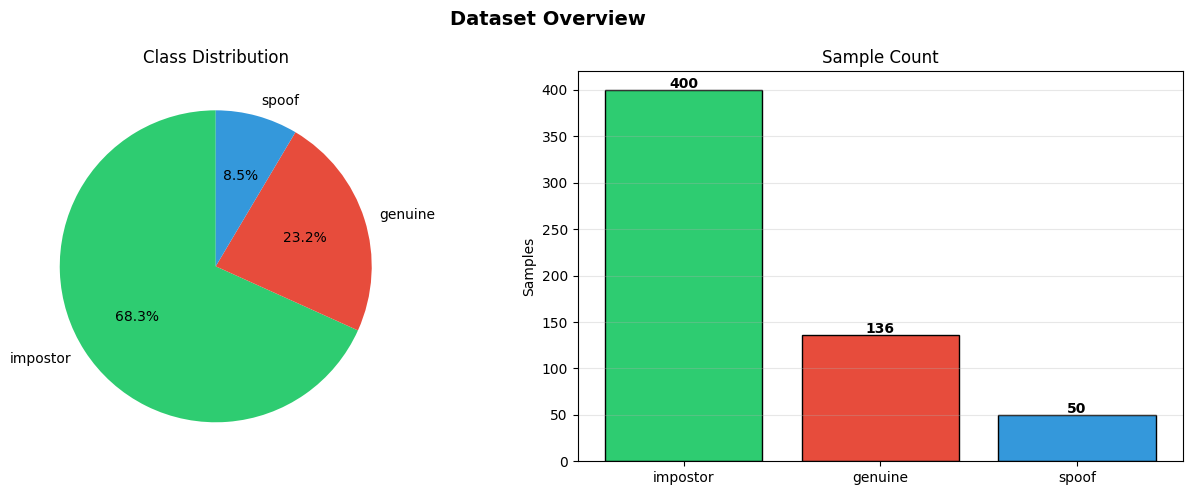

In [12]:
# Dataset distribution
counts = df_all['label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#3498db'], startangle=90)
axes[0].set_title('Class Distribution')

bars = axes[1].bar(counts.index, counts.values,
                   color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black')
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(v), ha='center', fontweight='bold')
axes[1].set_ylabel('Samples')
axes[1].set_title('Sample Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/results/dataset_distribution.png', dpi=150)
plt.show()

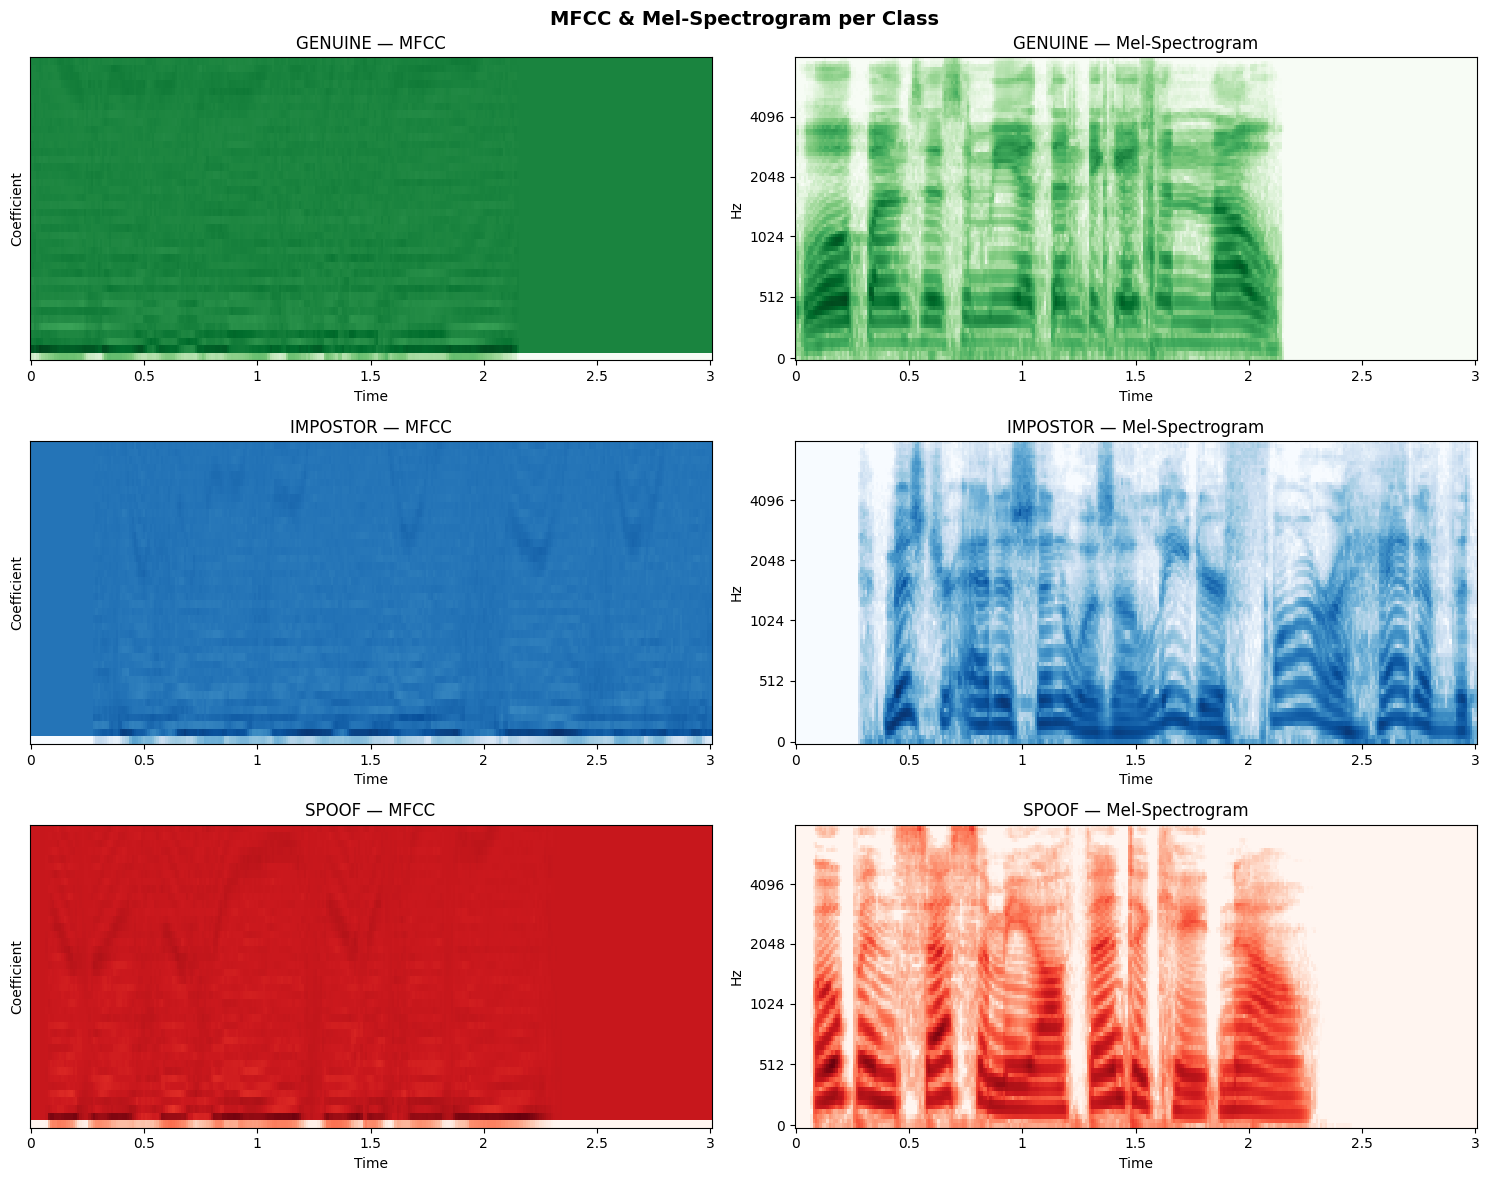

In [13]:
# Compare MFCC across classes
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('MFCC & Mel-Spectrogram per Class', fontsize=14, fontweight='bold')
label_colors = {'genuine': 'Greens', 'impostor': 'Blues', 'spoof': 'Reds'}

for row, label in enumerate(['genuine', 'impostor', 'spoof']):
    subset = df_all[df_all['label'] == label]
    if len(subset) == 0:
        continue
    row_data = subset.iloc[0]
    mfcc_d   = np.load(row_data['mfcc_file'])[:40]
    mel_d    = np.load(row_data['melspec_file'])

    librosa.display.specshow(mfcc_d, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', ax=axes[row, 0],
                             cmap=label_colors[label])
    axes[row, 0].set_title(f'{label.upper()} — MFCC')
    axes[row, 0].set_ylabel('Coefficient')

    librosa.display.specshow(mel_d, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[row, 1],
                             cmap=label_colors[label])
    axes[row, 1].set_title(f'{label.upper()} — Mel-Spectrogram')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/results/feature_comparison.png', dpi=150)
plt.show()

## Step 7: Train / Dev / Test Split

In [14]:
df_all = pd.read_csv(f'{BASE_DIR}/data/features_index.csv')

train_df, temp   = train_test_split(df_all, test_size=0.3,
                                    stratify=df_all['label'], random_state=42)
dev_df,   test_df = train_test_split(temp,  test_size=0.5,
                                    stratify=temp['label'],   random_state=42)

train_df.to_csv(f'{BASE_DIR}/data/train_index.csv', index=False)
dev_df.to_csv(  f'{BASE_DIR}/data/dev_index.csv',   index=False)
test_df.to_csv( f'{BASE_DIR}/data/test_index.csv',  index=False)

cfg = {
    'sample_rate': SAMPLE_RATE, 'n_mfcc': N_MFCC, 'n_mels': N_MELS,
    'hop_length': HOP_LENGTH, 'win_length': WIN_LENGTH, 'n_fft': N_FFT,
    'clip_duration': CLIP_DUR, 'base_dir': BASE_DIR,
    'total': len(df_all), 'train': len(train_df),
    'dev': len(dev_df), 'test': len(test_df),
    'class_counts': df_all['label'].value_counts().to_dict()
}
with open(f'{BASE_DIR}/data/phase1_summary.json', 'w') as f:
    json.dump(cfg, f, indent=2)

print('Phase 1 Complete!')
print(f'  Train : {len(train_df)}')
print(f'  Dev   : {len(dev_df)}')
print(f'  Test  : {len(test_df)}')
print(f'\nSaved to {BASE_DIR}/data/')

Phase 1 Complete!
  Train : 840
  Dev   : 180
  Test  : 180

Saved to /kaggle/working/voice_auth/data/
